## Processing input Spectronaut reports

### Import packages and set global config

In [1]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import scanpy as sc
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scdia.io import read_gene_matrix, calculate_sample_metrics, robust_gene_split

# set data and figure dir
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/'
fig_dir = 'SCP_Microglia/figures/1_1_io/'
results_dir = 'SCP_Microglia/results/1_1_io/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

sc.settings.verbosity = 3

In [ ]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

In [9]:
low_quality = {
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_A22",
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_B21",
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_B23",    
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_B24",
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_D24",
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_I18",
        "20241023_Io02_10min_1015_2M_male_PFC_MG_1c_P2_P20",
        "20241005_Io01_10min_0911_14M_male_PFC_MG_1c_P1_H22",
        "20241001_Io01_10min_0815_2M_male_PFC_MG_1c_P1_P12",
        "20241104_Io03_10min_0913_14M_male_PFC_MG_1c_P2_I15",
        "20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_F11",
        "20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_M8",
        "20241115_Io03_10min_1105_24M_male_HIP_MG_1c_P2_F9"
}
doublet = {
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_N1', 
        '20240927_Io01_10min_0911_14M_male_HIP_MG_1c_P1_K5', 
        '20241005_Io01_10min_0911_14M_male_PFC_MG_1c_P1_F7', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_A10', 
        '20240927_Io01_10min_0911_14M_male_HIP_MG_1c_P1_E8', 
        '20241104_Io03_10min_0913_14M_male_PFC_MG_1c_P2_I21', 
        '20241020_Io02_10min_1015_2M_male_PFC_MG_1c_P1_F22', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_P10', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_I4', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_L12', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_L13', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_M13', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_N19', 
        '20241027_Io02_10min_0822_24M_male_PFC_MG_1c_P1_C10', 
        '20240918_Io01_10min_0815_2M_male_HIP_MG_1c_P1_C22'
    }

cells_to_exclude = low_quality.union(doublet)

### Use Spectonaut MaxLFQ results
This part directly reads from the original Spectronaut report and generates the matrix, with the quality control standards remaining the same as above.

#### Read data

In [10]:
spectronaut_report_files = [f for f in os.listdir(data_dir + 'scpMS') if f.endswith('(Normal).tsv')]

spectronaut_report_files = [os.path.join(data_dir + 'scpMS', f) for f in spectronaut_report_files if f.endswith('(Normal).tsv')]

In [11]:
spectronaut_report_files

['/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io01_Part4_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io02_Part1_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io03_Part2_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io01_Part1_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io01_Part3_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io03_Part1_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_20c_summary_blank_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io02_Part2_noNorm_Report_SCP_Report_Normal (Normal).tsv',
 '/Volumes/SU700/scpMS_data/scpMS_microglia/scpMS/20250523_Io01_

In [12]:
maxlfq_gene_matrix = read_gene_matrix(
    spectronaut_report_files,
    engine="spectronaut",
    sample_col='R.FileName',
    quantity_mode="default",
    quality_filter=True,
    cleanup_filter=True,
    aggfunc="sum",
    gene_exclude_pattern=r'Igkv|Ighv|Try10|Alb|Krt|Amy',
    contaminant_proteingroups_pattern=r"CON_",
)

In [13]:
maxlfq_gene_matrix.iloc[:5, :5]

,Genes,ProteinGroups,20241016_Io01_10min_0913_14M_male_HIP_MG_1c_P1_A7,20241016_Io01_10min_0913_14M_male_HIP_MG_1c_P1_A9,20241016_Io01_10min_0913_14M_male_HIP_MG_1c_P1_A10
0,Magohb;Magoh;Magohb,A0A023T778;P61327;Q9CQL1,63.795246,285.091896,128.293777
1,Eloc,A0A087WNT1;A0A087WQE6;P83940,58.037922,NaN,50.198593
2,Dhx9,A0A087WPL5;E9QNN1;O70133|A0A087WPL5;E9QNN1,647.970886,1098.204140,1077.208832
3,Casp8,A0A087WQT6;O89110,74.685158,NaN,23.862007
4,Dap,A0A087WR57;A0A087WRC6;Q91XC8,31.468056,17.808485,15.465593


In [14]:
sample_metrics = calculate_sample_metrics(spectronaut_report_files)

In [15]:
# split gene groups into single gene
maxlfq_unique_gene_matrix = robust_gene_split(maxlfq_gene_matrix)

In [16]:
adata_maxlfq_gene = sc.AnnData(
    X = maxlfq_unique_gene_matrix.iloc[:, 1:].fillna(0).T.values, # fill na with 0 first
    obs = pd.DataFrame(index=maxlfq_unique_gene_matrix.columns[1:]),
    var = pd.DataFrame(index=maxlfq_unique_gene_matrix.iloc[:, 0])
)

In [17]:
adata_maxlfq_gene.obs.index.name = 'id'
adata_maxlfq_gene.var.index.name = 'Gene'

In [18]:
adata_maxlfq_gene = adata_maxlfq_gene[~adata_maxlfq_gene.obs.index.isin(cells_to_exclude)].copy()

In [19]:
adata_maxlfq_gene.obs = adata_maxlfq_gene.obs.assign(
            loading_date=lambda df: df.index.str.replace(r'_.*', '', regex=True),
            prepare_date=lambda df: df.index.str.replace(r'.*min_', '', regex=True).str.replace(r'_.*', '', regex=True),
            column_id=lambda df: df.index.str.replace(r'[0-9]{8}_', '', regex=True).str.replace(r'_.*', '', regex=True),
            LC_gradient=lambda df: df.index.str.replace(r'.*Io[0-9]{2}_', '', regex=True).str.replace(r'_.*', '', regex=True),
            celltype=lambda df: df.index.str.replace(r'.*HIP_|.*PFC_|_1c.*$|_20c.*$|_Blank.*$|_Debris.*$', '', regex=True),
            age=lambda df: df.index.str.replace(r'.*_[0-9]{4}_', '', regex=True).str.replace(r'_.*', '', regex=True),
            gender=lambda df: df.index.str.replace(r'.*M_', '', regex=True).str.replace(r'_.*', '', regex=True),
            brain_region=lambda df: df.index.str.replace(r'.*male_', '', regex=True).str.replace(r'_.*', '', regex=True),
            mass=lambda df: df.index.str.replace(r'.*MG_|.*CD45neg_', '', regex=True).str.replace(r'_.*', '', regex=True),
            plate_number=lambda df: df.index.str.replace(r'.*(Blank|1c|20c)_', '', regex=True).str.replace(r'_.*', '', regex=True),
            plate_location=lambda df: df.index.str.split('_').str[-1]
        )
adata_maxlfq_gene.obs['mass'] = adata_maxlfq_gene.obs['mass'].replace('Debris', 'Blank')

In [20]:
adata_maxlfq_gene.obs.reset_index(inplace=True)
adata_maxlfq_gene.obs = adata_maxlfq_gene.obs.merge(
    sample_metrics,
    left_on='id',
    right_on='sample',
    how='left'
)

In [21]:
adata_maxlfq_gene.obs.drop(columns=['sample'], inplace=True)
adata_maxlfq_gene.obs.set_index('id', inplace=True)

In [22]:
sc.pp.filter_genes(adata_maxlfq_gene, min_cells=1)

In [23]:
adata_maxlfq_gene

AnnData object with n_obs × n_vars = 3427 × 5858
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified'
    var: 'n_cells'

In [24]:
adata_maxlfq_gene.write(results_dir + 'scp_MG_all_maxlfq_gene.h5ad', compression='gzip')

In [25]:
adata_1c_maxlfq_gene = adata_maxlfq_gene[adata_maxlfq_gene.obs.mass == '1c'].copy()
adata_1c_maxlfq_gene = adata_1c_maxlfq_gene[adata_1c_maxlfq_gene.obs.celltype == 'MG'].copy()

sc.pp.filter_genes(adata_1c_maxlfq_gene, min_cells=1)

filtered out 1401 genes that are detected in less than 1 cells


In [26]:
adata_1c_maxlfq_gene

AnnData object with n_obs × n_vars = 3291 × 4457
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified'
    var: 'n_cells'

In [27]:
adata_1c_maxlfq_gene.write(results_dir + 'scp_MG_1c_maxlfq_gene.h5ad', compression='gzip')

### Plots

In [3]:
adata_maxlfq_gene = sc.read_h5ad(results_dir + 'scp_MG_all_maxlfq_gene.h5ad')
adata_1c_maxlfq_gene = sc.read_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene.h5ad')

#### Plot detection number distribution

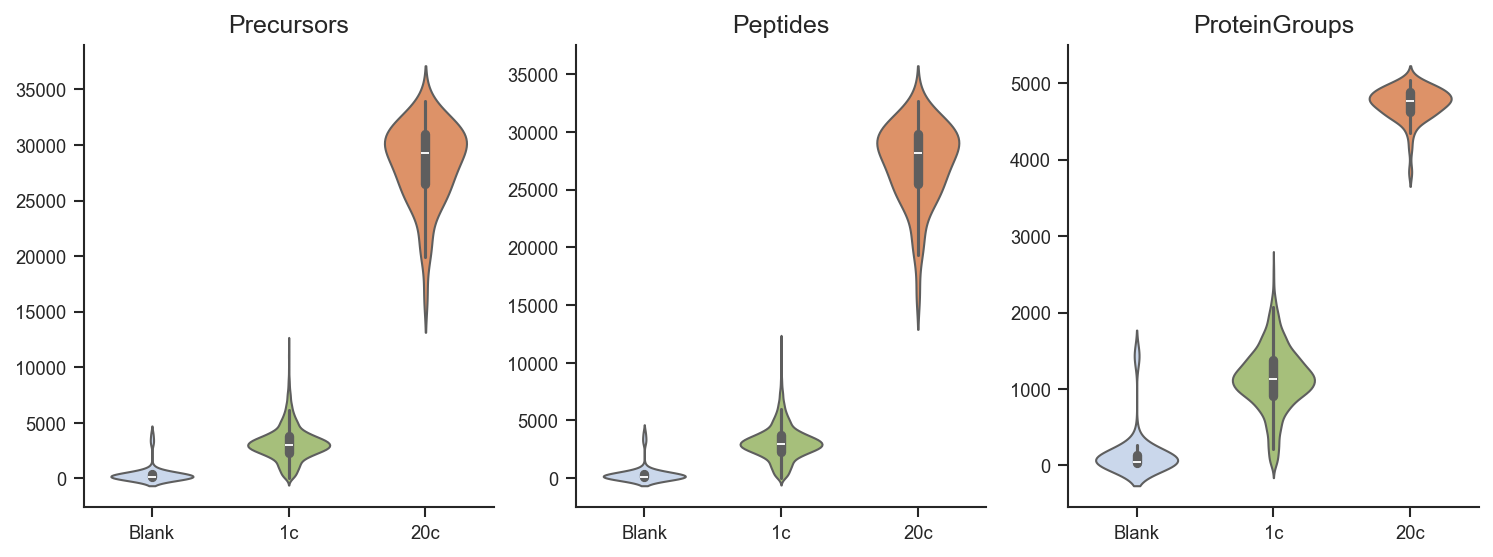

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = ['Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified']

paletee = ['#C5D6F0', '#A9CA70', '#F18C54']

for i, metric in enumerate(metrics):
    sns.violinplot(
        data=adata_maxlfq_gene.obs,
        x='mass',
        y=metric,
        order=['Blank', '1c', '20c'],
        hue='mass',
        hue_order=['Blank', '1c', '20c'],
        palette=paletee,
        ax=axes[i],
        inner='box',
        width=0.6
    )

    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].set_title(metric.split('_')[0], fontsize=12)

plt.savefig(fig_dir + 'identification_metrics_violinplot.pdf')

#### Detected Comparision

In [7]:
adata_1c_maxlfq_gene

genes_scp = set(adata_1c_maxlfq_gene.var_names)

In [9]:
protein_coding_genes = set(pd.read_csv(data_dir + 'scRNA-seq/mouse_protein_coding_gene_symbols.txt', header=None).iloc[:, 0].tolist())

len(protein_coding_genes)

21707

##### Li et al. 2019 Neuron

In [37]:
dataset_li = pd.read_csv(data_dir + 'scRNA-seq/Li_et-al_Neuron_2019.csv.gz', compression='gzip')
dataset_li.rename(columns={dataset_li.columns[0]: 'Gene'}, inplace=True)
dataset_li.set_index('Gene', inplace=True)

# filter empty rows
dataset_li = dataset_li[dataset_li.sum(axis=1) > 0]
genes_li = set(dataset_li.index)

genes_li_protein_coding = genes_li.intersection(protein_coding_genes)
print(f"Number of genes in Li dataset: {len(genes_li)}")

Number of genes in Li dataset: 17133


##### Masuda et al. 2019 Nature

In [42]:
dataset_masuda = pd.read_csv(data_dir + 'scRNA-seq/Masuda_et-al_Nature_2019.csv.gz', compression='gzip')

dataset_masuda.set_index(dataset_masuda.columns[0], inplace=True)

dataset_masuda = dataset_masuda.iloc[:, 5:]  # keep only single-cell data columns
dataset_masuda = dataset_masuda[dataset_masuda.sum(axis=1) > 0]  # filter empty rows

genes_masuda = set(dataset_masuda.index.unique())
genes_masuda_protein_coding = genes_masuda.intersection(protein_coding_genes)
print(f"Number of genes in Masuda dataset: {len(genes_masuda_protein_coding)}")

Number of genes in Masuda dataset: 18130


##### Hammond et al. 2019 Immunity

In [10]:
dataset_hammond = sc.read_h5ad(data_dir + 'scRNA-seq/Hammond_et-al_Immunity_2019.h5ad')

sc.pp.filter_genes(dataset_hammond, min_cells=1)

genes_hammond = set(dataset_hammond.var_names)
genes_hammond_protein_coding = genes_hammond.intersection(protein_coding_genes)
print(f"Number of genes in Hammond dataset: {len(genes_hammond_protein_coding)}")

filtered out 794 genes that are detected in less than 1 cells
Number of genes in Hammond dataset: 15079


In [44]:
del dataset_li, dataset_masuda, dataset_hammond  # release memory for large datasets

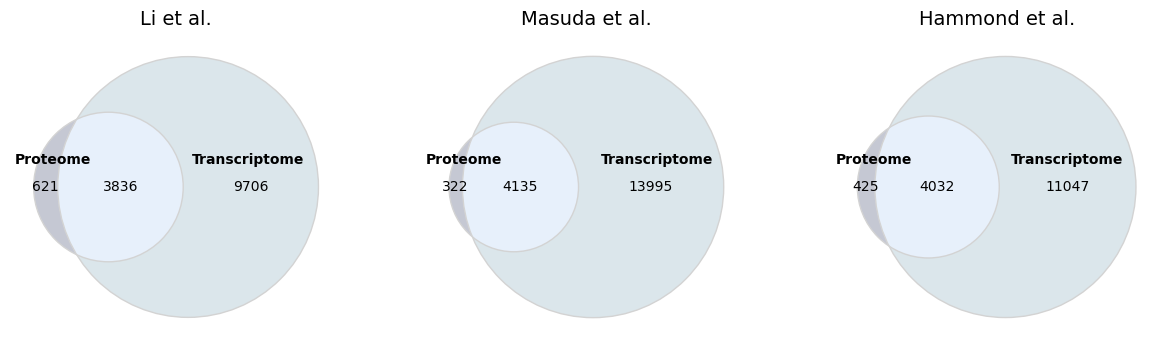

In [ ]:
# Venn diagram of gene overlap
from matplotlib_venn import venn2, venn2_circles

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

title_list = ['Li et al.', 'Masuda et al.', 'Hammond et al.']
for i, dataset in enumerate([genes_li_protein_coding, genes_masuda_protein_coding, genes_hammond_protein_coding]):
    v = venn2(
        [genes_scp, dataset], 
        set_labels=None,
        set_colors=('#6f7792', '#a7c1ce'),
        ax=axes[i]
    )
    venn2_circles(
        [genes_scp, dataset],
        linestyle='-',
        linewidth=1,
        color='lightgrey',
        ax=axes[i]
    )
    axes[i].set_title(title_list[i], fontsize=14)
    axes[i].text(-0.65, 0.1, 'Proteome', fontsize=10, fontweight='bold')
    axes[i].text(0.1, 0.1, 'Transcriptome', fontsize=10, fontweight='bold')

plt.savefig(fig_dir + 'gene_overlap_venn_diagram.pdf', dpi=300, bbox_inches='tight')
plt.show()

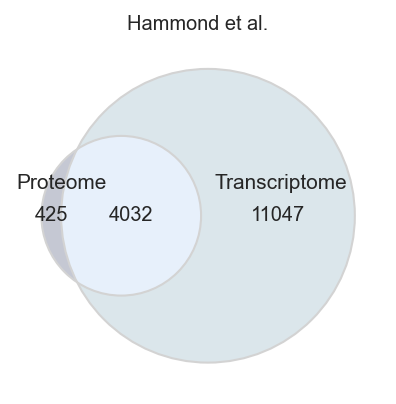

In [15]:
# Venn diagram of gene overlap
from matplotlib_venn import venn2, venn2_circles

fig, ax = plt.subplots(figsize=(4, 3))

v = venn2(
    [genes_scp, genes_hammond_protein_coding], 
    set_labels=None,
    set_colors=('#6f7792', '#a7c1ce'),
    ax=ax
)
venn2_circles(
    [genes_scp, genes_hammond_protein_coding],
    linestyle='-',
    linewidth=1,
    color='lightgrey',
    ax=ax
)

ax.set_title('Hammond et al.')
ax.text(-0.65, 0.1, 'Proteome', fontsize=10)
ax.text(0.1, 0.1, 'Transcriptome', fontsize=10)

plt.savefig(fig_dir + 'hammond_proteincoding_gene_overlap_venn_diagram.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Abundance Comparison

In [16]:
dataset_hammond = sc.read_h5ad(data_dir + 'scRNA-seq/Hammond_et-al_Immunity_2019.h5ad')

sc.pp.filter_genes(dataset_hammond, min_cells=1)
sc.pp.filter_cells(dataset_hammond, min_genes=200)

sc.pp.normalize_total(dataset_hammond, target_sum=1e4)
sc.pp.log1p(dataset_hammond)

filtered out 794 genes that are detected in less than 1 cells
normalizing counts per cell
    finished (0:00:00)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=5.200e+07


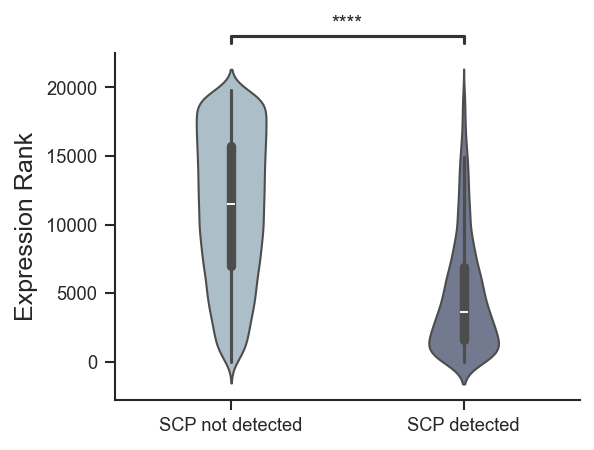

In [17]:
from statannotations.Annotator import Annotator

# get gene mean expression ranks
dataset_hammond.var['mean_expression'] = dataset_hammond.X.mean(axis=0).A1
dataset_hammond.var['expression_rank'] = dataset_hammond.var['mean_expression'].rank(ascending=False)
dataset_hammond.var['scp_detected'] = dataset_hammond.var_names.isin(genes_scp)

# compare expression ranks of SCP genes vs non-SCP genes
fig, ax = plt.subplots(figsize=(4, 3))
sns.violinplot(
    data=dataset_hammond.var,
    x='scp_detected',
    y='expression_rank',
    palette={'True': '#6f7792', 'False': '#a7c1ce'},
    width=0.3,
    ax=ax
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add statistical significance
annotator = Annotator(ax, pairs=[(True, False)], data=dataset_hammond.var, x='scp_detected', y='expression_rank')
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
annotator.apply_test()
annotator.annotate()

plt.xlabel('', fontsize=12)
plt.ylabel('Expression Rank', fontsize=12)
plt.xticks([0, 1], ['SCP not detected', 'SCP detected'])
plt.savefig(fig_dir + 'hammond_scp_expression_rank_violinplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Sample composition

In [18]:
%load_ext rpy2.ipython
obs_df = adata_1c_maxlfq_gene.obs[['age', 'brain_region', 'prepare_date', 'column_id']].copy()

plot_color_palettes = {
    'prepare_date': ["#3e608d", "#4e1945", "#8cbf87", "#8d2f25", "#909291", "#cb9475"],
    'column_id': ["#85D0FF", "#C2C48D", "#FFDC8E"],
    'brain_region': ["#ACD6EC", "#F5A889"],
    'age': ["#000000", "#2C939A", "#A6A3A4"]
}

stratum_names = []
stratum_colors = []
for col in ['age', 'brain_region', 'prepare_date', 'column_id']:
    unique_vals = sorted(obs_df[col].astype(str).dropna().unique())
    for val, color in zip(unique_vals, plot_color_palettes[col]):
        stratum_names.append(val)
        stratum_colors.append(color)

In [19]:
%%R -i obs_df -i stratum_names -i stratum_colors -w 8 -h 6 -u in
library(ggplot2)
library(ggalluvial)
library(dplyr)

obs_df$age <- as.character(obs_df$age)
obs_df$brain_region <- as.character(obs_df$brain_region)
obs_df$prepare_date <- as.character(obs_df$prepare_date)
obs_df$column_id <- as.character(obs_df$column_id)

color_mapping <- setNames(stratum_colors, stratum_names)

flow_data <- obs_df %>%
  group_by(age, brain_region, prepare_date, column_id) %>%
  summarise(Freq = n(), .groups = 'drop')

ggplot(as.data.frame(flow_data),
       aes(y = Freq, axis1 = age, axis2 = brain_region, axis3 = prepare_date, axis4 = column_id)) +
  geom_alluvium(aes(fill = "grey80"), width = 1/6, alpha = 0.6) +
  geom_stratum(aes(fill = after_stat(stratum)), width = 1/6, color = NA) +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3, color = "white") +
  scale_fill_manual(values = color_mapping) +
  scale_x_discrete(limits = c("Age", "Brain Region", "Prepare Date", "Column ID"), expand = c(.05, .05)) +
  theme_minimal() +
  theme(axis.text.x = element_text(size = 12, color = "black"),
        axis.text.y = element_blank(),
        axis.title.y = element_blank(),
        axis.ticks.y = element_blank(),
        legend.position = "none",
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank())

ggsave("SCP_Microglia/figures/1_1_io/metadata_flow_sankey.pdf", dpi=300, width = 12, height = 4, units = "in")


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

